In [66]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as  sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from collections import Counter

---
## **Load  Dataset**

In [2]:
df=pd.read_csv('D:\\Github\\PRODIGY_DS_04\\data\\twitter_training.csv')
df.columns = ['id', 'topic', 'sentiment', 'text']
df.head()

,id,topic,sentiment,text
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


---
## **Data Understanding**

In [3]:
df.shape,df.info(),df.describe(),df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         74681 non-null  int64 
 1   topic      74681 non-null  object
 2   sentiment  74681 non-null  object
 3   text       73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


((74681, 4),
 None,
                  id
 count  74681.000000
 mean    6432.640149
 std     3740.423819
 min        1.000000
 25%     3195.000000
 50%     6422.000000
 75%     9601.000000
 max    13200.000000,
          id        topic sentiment  \
 0      2401  Borderlands  Positive   
 1      2401  Borderlands  Positive   
 2      2401  Borderlands  Positive   
 3      2401  Borderlands  Positive   
 4      2401  Borderlands  Positive   
 ...     ...          ...       ...   
 74676  9200       Nvidia  Positive   
 74677  9200       Nvidia  Positive   
 74678  9200       Nvidia  Positive   
 74679  9200       Nvidia  Positive   
 74680  9200       Nvidia  Positive   
 
                                                     text  
 0      I am coming to the borders and I will kill you...  
 1      im getting on borderlands and i will kill you ...  
 2      im coming on borderlands and i will murder you...  
 3      im getting on borderlands 2 and i will murder ...  
 4      im getting i

In [4]:
df.select_dtypes(include='number').columns.to_list()

['id']

In [5]:
df.select_dtypes(include='object').columns.to_list()


['topic', 'sentiment', 'text']

In [6]:
df.sample(10,random_state=42)

,id,topic,sentiment,text
34877,6792,Fortnite,Irrelevant,went to go in george's room to find his door w...
21704,4115,CS-GO,Positive,Yo this looks LIT! Team:GO/Overwatch combo
47008,5665,HomeDepot,Negative,Pay attention executive administrators. While ...
7969,9369,Overwatch,Irrelevant,Guy looked at me and says my name was put on t...
454,2476,Borderlands,Positive,one
58076,11558,TomClancysRainbowSix,Negative,@Rainbow6Game Server are Available in Xbox 🥺
39653,1208,Battlefield,Irrelevant,A ban for Battlefield 4 player lIlColdllI has ...
51601,10458,RedDeadRedemption(RDR),Irrelevant,lmao gason might kill me for this
23819,4482,Google,Irrelevant,pls google the definitions of words before usi...
62213,5065,GrandTheftAuto(GTA),Irrelevant,After them cops ran a crowd of peaceful protes...


In [7]:
df[df['text'].str.strip()==''].sum()



id                                                     1156176
topic        CallOfDutyBlackopsColdWarCallOfDutyBlackopsCol...
sentiment    IrrelevantPositiveNeutralNegativeNegativeNeutr...
text                                                       ...
dtype: object

In [8]:

df['text'].str.contains('http').sum()
df['text'].apply(lambda x: bool(re.search(r'http\S+', str(x)))).sum()

np.int64(2430)

In [9]:
df['text'].str.contains('@').sum()

18309

In [10]:
df['text'].str.contains('#').sum()

35

In [11]:
df['text'].apply(lambda x: any(char in str(x) for char in ['😀','😂','🔥','❤️'])).sum()

np.int64(0)

In [12]:
df['text'].apply(lambda x: bool(re.search(r'[^a-zA-Z0-9\s]', str(x)))).sum()

np.int64(64669)

In [13]:
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))
df[df['text_length'] < 3]


,id,topic,sentiment,text,text_length
10,2402,Borderlands,Positive,was,1
52,2409,Borderlands,Neutral,all,1
60,2411,Borderlands,Neutral,NaN,1
61,2411,Borderlands,Neutral,.. [,2
62,2411,Borderlands,Neutral,.. 45,2
...,...,...,...,...,...
74527,9175,Nvidia,Neutral,What next?,2
74590,9185,Nvidia,Neutral,you,1
74596,9186,Nvidia,Positive,from,1
74620,9190,Nvidia,Positive,were,1


---
## **Data Cleaning**

### Remove Empty Text and Null values

In [14]:
df.isna().sum()


id               0
topic            0
sentiment        0
text           686
text_length      0
dtype: int64

In [15]:
df=df.dropna(subset=['text'])
df=df[df['text'].str.strip()!='']
df[df['text'].str.strip()==''].sum()
df.isna().sum()

id             0
topic          0
sentiment      0
text           0
text_length    0
dtype: int64

### Remove Duplicates

In [24]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

### Remove Short Text

In [26]:
df=df[df['text_length'] >= 3]

### Convert Text into lower case

In [27]:
df['text']=df['text'].str.lower()

### Remove URLs, Mentions(@), Hash(#), Numbers, Punctions, Extra Whitespaces

In [28]:
df['text'] = df['text'].apply(lambda x: re.sub(r'http\S+|www\S+', '', x))
df['text'] = df['text'].apply(lambda x: re.sub(r'@\w+', '', x))
df['text'] = df['text'].apply(lambda x: re.sub(r'#', '', x))
df['text'] = df['text'].apply(lambda x: re.sub(r'\d+', '', x))
df['text'] = df['text'].apply(lambda x: re.sub(r'[^\w\s]', '', x))
df['text'] = df['text'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

In [29]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Professor\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Professor\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Professor\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [21]:

nltk.download('punkt_tab')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Professor\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Professor\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

### Remove Stopwords + Lemmatization

In [30]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_and_lemmatize(text):
    text = str(text)  # ensure string
    tokens = word_tokenize(text)
    filtered_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]
    return " ".join(filtered_tokens)

df['clean_text'] = df['text'].apply(clean_and_lemmatize)

In [31]:
df[['text', 'clean_text']].sample(5)

,text,clean_text
74356,it wont work i tried reposting it so slightly ...,wont work tried reposting slightly different
50293,happy birthday novysir from to the world cup w...,happy birthday novysir world cup great honor
39254,for some reason living room appears epic in th...,reason living room appears epic latest change ...
14236,gabe taylor is,gabe taylor
74076,nvidia fixes code execution errors in geforce ...,nvidia fix code execution error geforce experi...


---
## **Exploratory Data Analysis**

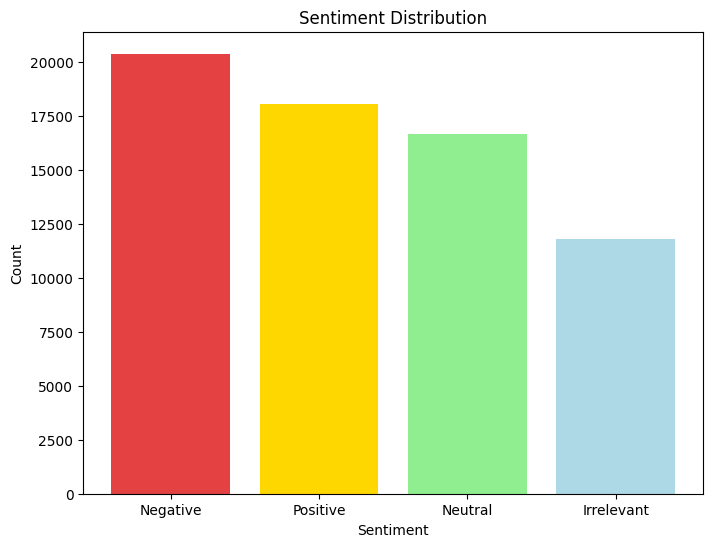

In [ ]:
sentiment_data=df['sentiment'].value_counts().reset_index()
plt.figure(figsize=(8,6))
plt.bar(sentiment_data['sentiment'],sentiment_data['count'],color=[ "#e44242",'gold','lightgreen','lightblue'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

# Insight : 30% negative seniments, 26% Positive , 24% Neutral and 17% Irrelevant sentiments
# Dataset is not that imbalance

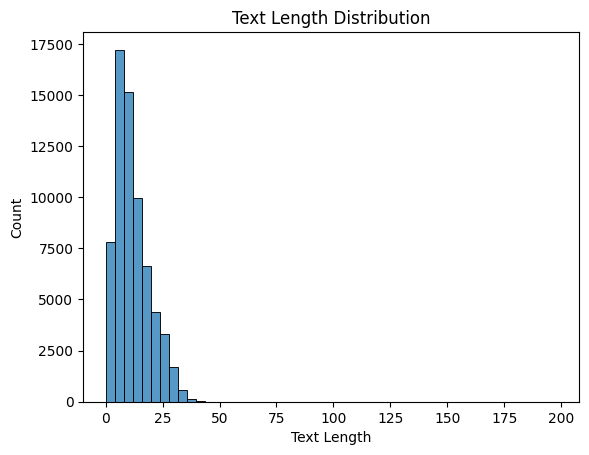

In [ ]:
df['text_length'] = df['clean_text'].apply(lambda x: len(str(x).split()))
sns.histplot(df['text_length'],bins=50)
plt.title('Text Length Distribution')
plt.xlabel('Text Length')
plt.show()

# Insight : Mostly text length lies between  5-25

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# 1. Combine all clean text into one massive string
# (We use dropna() and astype(str) just in case there are missing or weird values)
all_text = ' '.join(df['clean_text'].dropna().astype(str))

# 2. Split the text into individual words and count them
word_counts = Counter(all_text.split())

# 3. Get the Top 20 most common words 
# (This returns a list of pairs like [('apple', 50), ('banana', 40)])
top_20_words = word_counts.most_common(20)

# Convert to a DataFrame so Seaborn can easily plot it
top_words_df = pd.DataFrame(top_20_words, columns=['Word', 'Frequency'])

# Display the exact numbers
print("--- Top 20 Words ---")
print(top_words_df)

# 4. Plot the Bar Chart
plt.figure(figsize=(12, 8))

# Using a horizontal bar plot (x='Frequency', y='Word') makes the words much easier to read!
sns.barplot(data=top_words_df, x='Frequency', y='Word', palette='magma')

plt.title('Top 20 Most Frequent Words in Discussions', fontsize=16, weight='bold')
plt.xlabel('Frequency (Number of Appearances)', fontsize=12)
plt.ylabel('Word', fontsize=12)

# Remove the top and right borders for a cleaner look
sns.despine()

plt.show()

C:\Users\Professor\AppData\Local\Temp\ipykernel_15472\410946507.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_words_df,x='Frequency',y='Word',palette='magma')


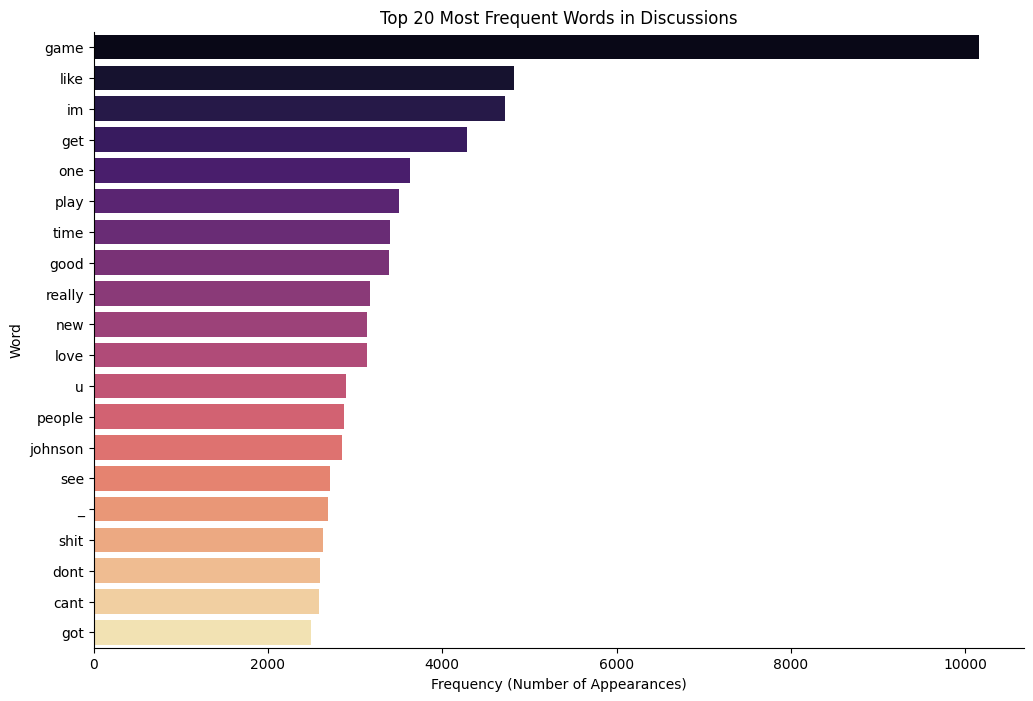

In [78]:
all_text=' '.join(df['clean_text'].dropna().astype(str))
word_counts=Counter(all_text.split())
top_20_words=word_counts.most_common(20)
plt.figure(figsize=(12, 8))
top_words_df=pd.DataFrame(top_20_words,columns=['Word','Frequency'])
sns.barplot(data=top_words_df,x='Frequency',y='Word',palette='magma')
plt.title('Top 20 Most Frequent Words in Discussions')
plt.xlabel('Frequency (Number of Appearances)')
plt.ylabel('Word')
sns.despine()
plt.show()